# FLARE to NPZ Conversion and Visualization

This notebook converts FLARE dataset `.nii.gz` files into a unified `.npz` format for testing.

In [1]:
import sys
from pathlib import Path
import os
import numpy as np

# Ensure project root is on sys.path
parent = Path().resolve().parent.parent 
if str(parent) not in sys.path:
    sys.path.append(str(parent))

from data.test_data.flare_to_npz import process_flare_dataset
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices, plot_one_dp

## 1. Process FLARE Dataset

We use the `process_flare_dataset` function to resample images and masks to 1.0mm isotropic resolution (without cropping).

In [2]:
data_dir = "FLARE"
output_name = "FLARE"

if os.path.isdir(data_dir):
    process_flare_dataset(data_dir, output_name)
else:
    print(f"Data directory {data_dir} not found. Please ensure it exists.")


[1/10] Processing train_000 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('2.50', '0.64', '0.64') mm → 1.0 mm isotropic ...
  -> Resampled shape: (258, 308, 330)

[2/10] Processing train_016 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('2.50', '0.61', '0.61') mm → 1.0 mm isotropic ...
  -> Resampled shape: (182, 267, 304)

[3/10] Processing train_046 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('2.50', '0.73', '0.73') mm → 1.0 mm isotropic ...
  -> Resampled shape: (205, 282, 372)

[4/10] Processing train_118 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('2.50', '0.80', '0.80') mm → 1.0 mm isotropic ...
  -> Resampled shape: (238, 351, 389)

[5/10] Processing train_145 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('2.50', '0.86', '0.86') mm → 1.0 mm isotropic ...
  -> Resampled shape: (202, 346, 440)

[6/10] Processing train_168 ...
  Cropping to anatomy (margin=15) ...

## 2. Load and Visualize

Now we load the generated `.npz` file and visualize a few samples.

In [3]:
npz_path = f"data/test_data/{output_name}.npz"

dg = DataGenerator(DataLoader_npz([npz_path], val_size=0.0))
all_ids = dg.dataloader.train_ids
print(f"Loaded IDs: {all_ids}")

sample_id = all_ids[0]
img = dg.dataloader.dataset[sample_id]['image']
mask = dg.dataloader.dataset[sample_id]['segmentations']

print(f"Sample: {sample_id}")
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask[0].shape}")


Loading NPZ dataset(s)…
Loaded 10 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\FLARE.npz

Final dataset size: 10 patients.

Loaded IDs: ['FLARE_train_168', 'FLARE_train_000', 'FLARE_train_315', 'FLARE_train_205', 'FLARE_train_118', 'FLARE_train_046', 'FLARE_train_145', 'FLARE_train_016', 'FLARE_train_182', 'FLARE_train_285']
Sample: FLARE_train_168
Image shape: (218, 352, 410)
Mask shape: (218, 352, 410)


### Interactive Visualization

Note: This interactive view will not be saved when you restart the notebook.

In [4]:
visualize_img_with_mask(img, mask[0])

interactive(children=(IntSlider(value=109, description='Slice:', max=217), Output()), _dom_classes=('widget-in…

### Static Persistent Visualization

This grid view is saved in the notebook, so you can see it later even without a running kernel.

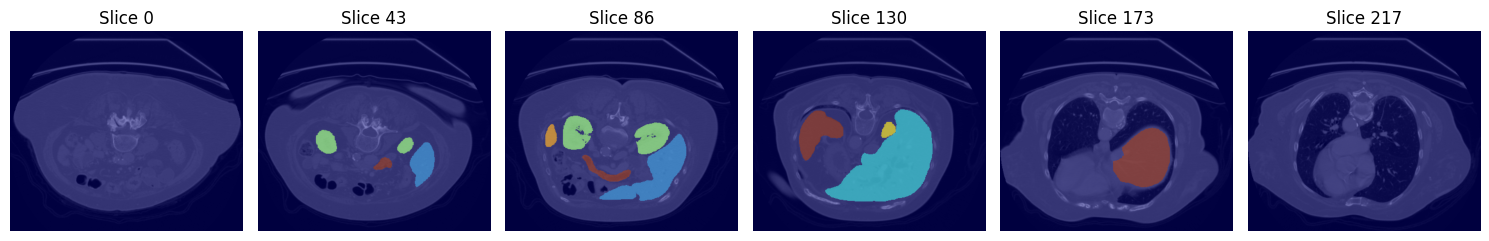

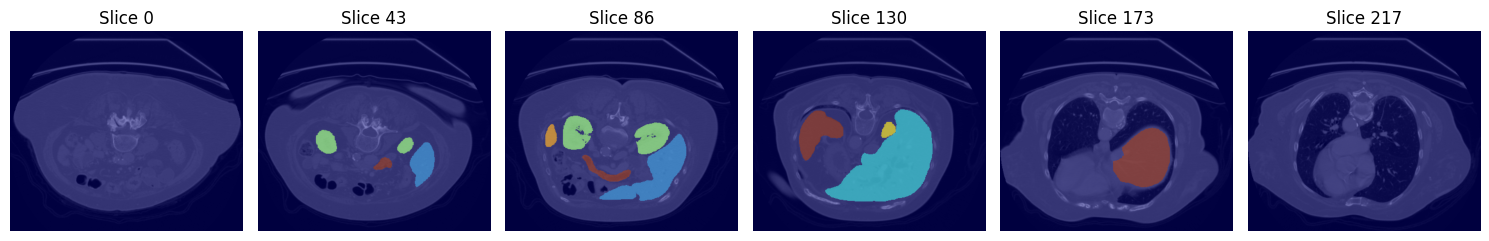

In [5]:
plot_vol_slices(img, mask[0], num_slices=6)

In [18]:
x_np, y_np, p_np, m_np, offset_list = dg.get_data_points_numpy(max_data_points=100, offset=10, max_number_labels=3)

Creating new Data Points ...
It took 1 seconds


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.86315596..5.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79094994..5.0].


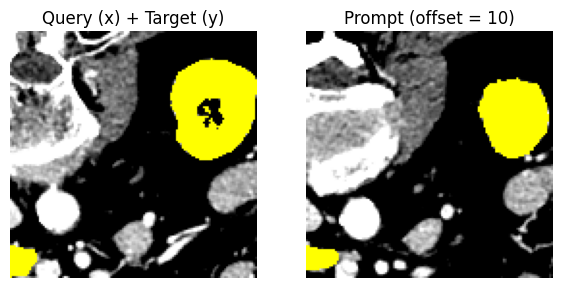

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7615342..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8102952..5.0].



x: -0.8631559610366821 - 5.0 | y: 0.0 - 1.0 | p (img): -0.7909499406814575 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


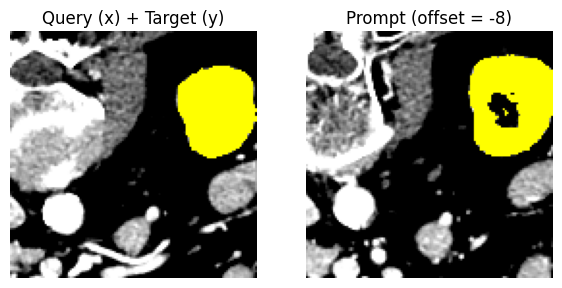

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.2582483].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.2758322].



x: -0.7615342140197754 - 5.0 | y: 0.0 - 1.0 | p (img): -0.8102952241897583 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


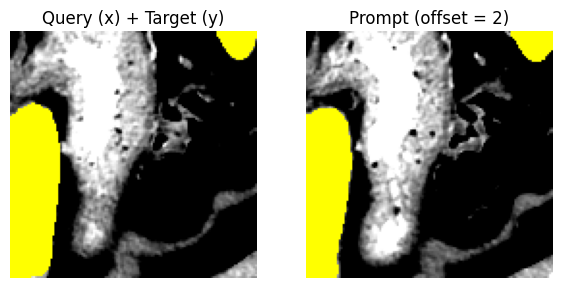

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 2.2582483291625977 | y: 0.0 - 1.0 | p (img): -5.0 - 2.275832176208496 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


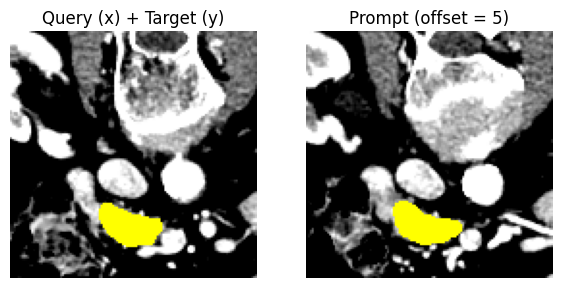

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


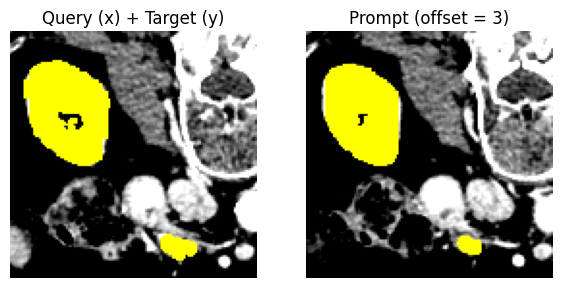

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..1.9421495].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.3274174].



x: -5.0 - 5.0 | y: 0.0 - 1.0 | p (img): -5.0 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


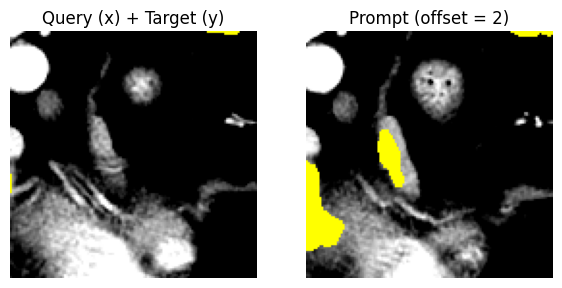


x: -5.0 - 1.9421495199203491 | y: 0.0 - 1.0 | p (img): -5.0 - 2.3274173736572266 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


In [22]:
for dp_idx in range(x_np.shape[0]):
    x, y, p = x_np[dp_idx,...], y_np[dp_idx,...], p_np[dp_idx,...]
    plot_one_dp(x,y,p, offset_list[dp_idx])
    print(f'x: {np.min(x)} - {np.max(x)} | y: {np.min(y)} - {np.max(y)} | p (img): {np.min(p[...,0])} - {np.max(p[...,0])} | p (roi): {np.min(p[...,1])} - {np.max(p[...,1])}')
    print(np.unique(y), np.unique(p[...,1]))
    print(x.dtype, y.dtype, p[...,0].dtype, p[...,1].dtype)
    if dp_idx == 5:
        break